------------


## Evaluación de distintos modelos.

Usando mnist como dataset
Encontrados 8 pares de modelos.

🧩 Cargando modelos para configuración: cvae_1024_lat_256_mnist.keras
✅ Modelo 'cvae_1024_lat_256_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_1024_lat_512_mnist.keras
✅ Modelo 'cvae_1024_lat_512_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_128_lat_2_mnist.keras
✅ Modelo 'cvae_128_lat_2_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_128_lat_64_mnist.keras
✅ Modelo 'cvae_128_lat_64_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_256_lat_128_mnist.keras
✅ Modelo 'cvae_256_lat_128_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_256_lat_64_mnist.keras
✅ Modelo 'cvae_256_lat_64_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_512_lat_128_mnist.keras
✅ Modelo 'cvae_512_lat_128_mnist.keras' procesado.

🧩 Cargando modelos para configuración: cvae_512_lat_256_mnist.keras
✅ Modelo 'cvae_512_lat_256_mnist.kera

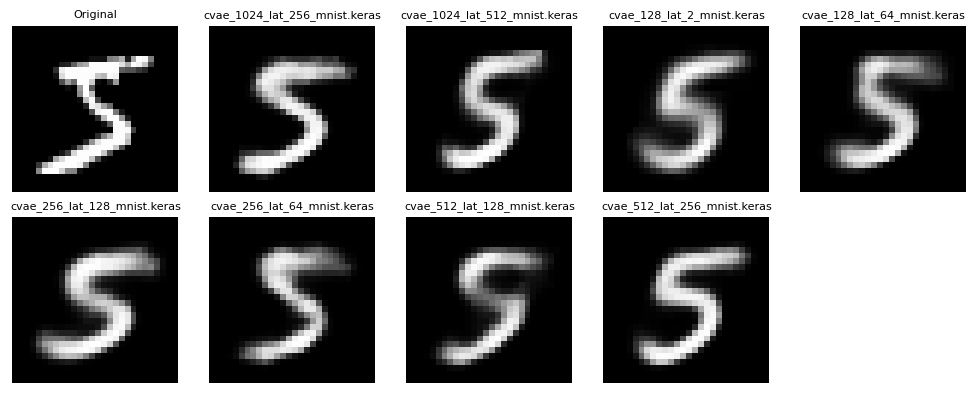

In [15]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(),"../../..")))
from project.trained_models import load 
import matplotlib.pyplot as plt
from project.CROP.utitls.metrics import Metrics 



# Cargar datos
dataset = "mnist" 
#dataset = "fashion"
data = load.data(dataset)
x_train = data["x_train"]
x_test = data["x_test"]
x_val = data["x_val"]
y_train = data["y_train"]
y_test = data["y_test"]
y_val = data["y_val"]
x_train_1 = data["x_train_1"]
y_train_1 = data["y_train_1"]  


models = load.all_models(dataset=dataset)

# Imagen original
x_input = x_train[:1]         # Imagen original
cond_input = y_train[:1]      # Condición
original_image = x_input[0].reshape(28, 28)

# Guardar imágenes reconstruidas + nombres
reconstructed_images = [original_image]
model_names = ["Original"]

# Iterar sobre modelos
for m in models:
    print(f"\n🧩 Cargando modelos para configuración: {m.name}")

    # Codificar y decodificar
    z_mean, z_log_var, z = m.encoder.predict([x_input, cond_input],verbose=0)
    reconstructed = m.decoder.predict([z, cond_input],verbose=0)

    # Guardar imagen
    reconstructed_images.append(reconstructed[0].reshape(28, 28))
    model_names.append(m.name)

    print(f"✅ Modelo '{m.name}' procesado.")

# Mostrar todas las imágenes en una sola figura
num_images = len(reconstructed_images)
cols = min(5, num_images)
rows = (num_images + cols - 1) // cols

plt.figure(figsize=(cols * 2, rows * 2))
print(len(reconstructed_images))
print(reconstructed_images[0])

for i, (img, name) in enumerate(zip(reconstructed_images, model_names)):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(name, fontsize=8)
    plt.axis("off")
    print( Metrics.ssim_grayscale(target=reconstructed_images[0], preds=img))
       
plt.tight_layout()
plt.show()


Si bien se observar diferencias apreciables en cada modelo, no parece haber un modelo que genere una reconstrucción apreciablemetne mejor

# Error de reconstrucción por modelo

In [1]:

import os
import sys
import tensorflow as tf

# Agregar carpeta raíz al path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from experiments import load

#models = all_models()#revisar
models = []

inter = [128,128,256,256,512,1024]
lat = [2,64,64,128,256,256]
dataset = "mnist"

# Suprime mensajes de TensorFlow
import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


for i, l in zip(inter,lat):
    models.append(load.cvae(lat=l,inter=i,dataset=dataset))

data = load.data(dataset="mnist")
x_test = data["x_test"]
y_test = data["y_test"]

x_sample = x_test[:10000]
y_sample = y_test[:10000]

reconstruction_errors = []

for i, model in enumerate(models):
    # Generar reconstruccione
    reconstructions = model.predict((x_sample, y_sample), verbose=0)

    # Calcular error de reconstrucción promedio (MSE)
    mse = tf.reduce_mean(
        tf.keras.losses.mse(
            tf.reshape(x_sample, [x_sample.shape[0], -1]),
            tf.reshape(reconstructions, [reconstructions.shape[0], -1])
        )
    ).numpy()

    reconstruction_errors.append(mse)
    print(f"Modelo {model.name}: reconstruction MSE = {mse:.4f}")


2025-08-20 20:27:18.976337: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 20:27:18.981954: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-20 20:27:19.002141: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755732439.033988  777951 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755732439.043001  777951 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755732439.059913  777951 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Usando mnist como dataset
Modelo cvae_laten_2_inter_128_mnist: reconstruction MSE = 0.0347
Modelo cvae_laten_64_inter_128_mnist: reconstruction MSE = 0.0231
Modelo cvae_laten_64_inter_256_mnist: reconstruction MSE = 0.0214
Modelo cvae_laten_128_inter_256_mnist: reconstruction MSE = 0.0221
Modelo cvae_laten_256_inter_512_mnist: reconstruction MSE = 0.0217
Modelo cvae_laten_256_inter_1024_mnist: reconstruction MSE = 0.0214


Hay un menor error de reconstrucción con forme crece el el número de paramentros. Sin embargo no parece haber una diferencia apreciable para los modelos de 256-128 y de 512-256. El error de reconstrucción es practicamente el mismo. 

Repetimos para Fashion

In [2]:

import os
import sys
import tensorflow as tf

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load

dataset = "fashion"

data = load.data(dataset=dataset)

models = []

inter = [128,128, 256, 256 ,512 ,1024]
lat =   [2,  64 , 64 , 128 ,128 ,256]

# Suprime mensajes de TensorFlow
import logging
tf.get_logger().setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


for i, l in zip(inter,lat):
    models.append(load.cvae(lat=l,inter=i,dataset=dataset))

x_test = data["x_test"]
y_test = data["y_test"]

x_sample = x_test[:10000]
y_sample = y_test[:10000]

reconstruction_errors = []

for i, model in enumerate(models):
    # Generar reconstruccione
    reconstructions = model.predict((x_sample, y_sample), verbose=0)

    # Calcular error de reconstrucción promedio (MSE)
    mse = tf.reduce_mean(
        tf.keras.losses.mse(
            tf.reshape(x_sample, [x_sample.shape[0], -1]),
            tf.reshape(reconstructions, [reconstructions.shape[0], -1])
        )
    ).numpy()

    reconstruction_errors.append(mse)
    print(f"Modelo {model.name}: reconstruction MSE = {mse:.4f}")


Usando fashion como dataset
Modelo cvae_laten_2_inter_128_fashion: reconstruction MSE = 0.0261
Modelo cvae_laten_64_inter_128_fashion: reconstruction MSE = 0.0219
Modelo cvae_laten_64_inter_256_fashion: reconstruction MSE = 0.0201
Modelo cvae_laten_128_inter_256_fashion: reconstruction MSE = 0.0238
Modelo cvae_laten_128_inter_512_fashion: reconstruction MSE = 0.0201
Modelo cvae_laten_256_inter_1024_fashion: reconstruction MSE = 0.0206


El modelo 0, 3 y 4  tiene un rendimiento muy similiar ( 128-2 512-128  y 1024-256). Parecen ser los más optimos para esto.

## Evaluación de separación 

In [7]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop import crop


dataset="fashion"

crops = []
inter = [128,128, 256, 256 ,512 ,1024]
lat =   [2,  64 , 64 , 128 ,128 ,256]

predictor = load.predictor(dataset) 
data = load.data(dataset=dataset)

for i, l in zip(inter,lat):
    crops.append(crop(load.cvae(lat=l,inter=i,dataset=dataset),predictor=predictor,data=dataset))


x_test = data["x_test"]
y_test = data["y_test"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]

num_images = 1000

x_sample = x_test[:num_images]
y_sample = y_test[:num_images]
x_sample_1 = x_test_1[:num_images]
y_sample_1 = y_test_1[:num_images]

print(crops[0])


bpsnrs = []

for model in crops:
    metrics = model.unmix(x_sample ,x_sample_1, y_sample,y_sample_1)
    bpsnrs.append(metrics["bpsnr"][0])
    print(f"Modelo {model.name}: bpsnr = {metrics["bpsnr"][0]:.4f}")


Usando fashion como dataset
Modelo cvae_laten_2_inter_128_fashion: bpsnr = 14.4935
Modelo cvae_laten_64_inter_128_fashion: bpsnr = 14.9323
Modelo cvae_laten_64_inter_256_fashion: bpsnr = 15.1339
Modelo cvae_laten_128_inter_256_fashion: bpsnr = 14.9736
Modelo cvae_laten_128_inter_512_fashion: bpsnr = 15.0801
Modelo cvae_laten_256_inter_1024_fashion: bpsnr = 15.1898


Encontrados 6 pares de modelos.
Usando fashion como dataset
Modelo cvae_laten_2_inter_128_fashion: bpsnr = 14.4935
Modelo cvae_laten_64_inter_128_fashion: bpsnr = 14.9323
Modelo cvae_laten_64_inter_256_fashion: bpsnr = 15.1339
Modelo cvae_laten_128_inter_256_fashion: bpsnr = 14.9736
Modelo cvae_laten_128_inter_512_fashion: bpsnr = 15.0801
Modelo cvae_laten_256_inter_1024_fashion: bpsnr = 15.1898
Con lo smodelos de fashion mnist, vemos que el el modelo número 1 (128-64) tiene la mejor bpsnr. 

In [8]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))
from experiments import load
from CROP_models.crop import crop


dataset="mnist"

crops = []
inter = [128,128, 256, 256 ,512 ,1024]
lat =   [2,  64 , 64 , 128 ,256 ,256]

predictor = load.predictor(dataset) 
data = load.data(dataset=dataset)

for i, l in zip(inter,lat):
    crops.append(crop(load.cvae(lat=l,inter=i,dataset=dataset),predictor=predictor,data=dataset))


x_test = data["x_test"]
y_test = data["y_test"]
x_test_1 = data["x_test_1"]
y_test_1 = data["y_test_1"]

num_images = 1000

x_sample = x_test[:num_images]
y_sample = y_test[:num_images]
x_sample_1 = x_test_1[:num_images]
y_sample_1 = y_test_1[:num_images]

print(crops[0])


bpsnrs = []

for model in crops:
    metrics = model.unmix(x_sample ,x_sample_1, y_sample,y_sample_1)
    bpsnrs.append(metrics["bpsnr"][0])
    print(f"Modelo {model.name}: bpsnr = {metrics["bpsnr"][0]:.4f}")


Usando mnist como dataset
Modelo cvae_laten_2_inter_128_mnist: bpsnr = 15.2722
Modelo cvae_laten_64_inter_128_mnist: bpsnr = 16.8195
Modelo cvae_laten_64_inter_256_mnist: bpsnr = 17.0887
Modelo cvae_laten_128_inter_256_mnist: bpsnr = 16.9986
Modelo cvae_laten_256_inter_512_mnist: bpsnr = 17.0562
Modelo cvae_laten_256_inter_1024_mnist: bpsnr = 17.1000


Encontrados 6 pares de modelos.
Usando mnist como dataset
Modelo cvae_laten_2_inter_128_mnist: bpsnr = 15.2722
Modelo cvae_laten_64_inter_128_mnist: bpsnr = 16.8195
Modelo cvae_laten_64_inter_256_mnist: bpsnr = 17.0887
Modelo cvae_laten_128_inter_256_mnist: bpsnr = 16.9986
Modelo cvae_laten_256_inter_512_mnist: bpsnr = 17.0562
Modelo cvae_laten_256_inter_1024_mnist: bpsnr = 17.1000

con estos experimientos parece ser que el mejor modelo para esta tarea es el modelo de 128-64 parametros 